In [ ]:

# Install required packages
!pip install roboflow ultralytics -q

# Mount Google Drive to save models
from google.colab import drive
drive.mount('/content/drive')

# Import libraries
from roboflow import Roboflow
from ultralytics import YOLO
import os
import yaml
from pathlib import Path


Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# =============================================================================
# 1. DOWNLOAD DATASET FROM ROBOFLOW
# =============================================================================
print(" Downloading dataset from Roboflow...")
rf = Roboflow(api_key="9B6cj89t8J15DA1a7rne")
project = rf.workspace("dhruv-kandpal-ewuck").project("road-object-detection-devp5")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to road-object-detection-1 in yolov8:: 100%|██████████| 31306/31306 [00:05<00:00, 5534.82it/s]


In [ ]:
# =============================================================================
# 2. SETUP PATHS
# =============================================================================
dataset_path = f"{dataset.location}/data.yaml"
save_dir = "/content/drive/MyDrive/YOLOv8_RoadDetection"
os.makedirs(save_dir, exist_ok=True)

print(f"Dataset downloaded to: {dataset.location}")
print(f"Models will be saved to: {save_dir}")

Dataset downloaded to: /content/road-object-detection-1
Models will be saved to: /content/drive/MyDrive/YOLOv8_RoadDetection


In [ ]:
# =============================================================================
# 3. VERIFY AND UPDATE DATA.YAML
# =============================================================================
with open(dataset_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("\n Dataset Configuration:")
print(f"Classes: {data_config['names']}")
print(f"Number of classes: {data_config['nc']}")


 Dataset Configuration:
Classes: ['animal', 'autorickshaw', 'bicycle', 'bus', 'car', 'caravan', 'motorcycle', 'person', 'rider', 'traffic light', 'traffic sign', 'trailer', 'train', 'truck', 'vehicle fallback']
Number of classes: 15


In [ ]:
# =============================================================================
# 4. INITIALIZE YOLOV8 MODEL
# =============================================================================
print("\n Initializing YOLOv8 model...")
model = YOLO('yolov8n.pt')


 Initializing YOLOv8 model...


In [ ]:
# =============================================================================
# 5. TRAIN MODEL WITH AUGMENTATION AND OPTIMIZATION
# =============================================================================
print("\n Starting training...")

results = model.train(
    # Dataset Configuration
    data=dataset_path,

    # Training Parameters
    epochs=100,                    # Number of training epochs
    imgsz=640,                     # Image size (640x640)
    batch=16,                      # Batch size (adjust based on GPU memory)

    # Learning Rate & Optimization
    lr0=0.01,                      # Initial learning rate
    lrf=0.01,                      # Final learning rate (lr0 * lrf)
    momentum=0.937,                # SGD momentum
    weight_decay=0.0005,           # Optimizer weight decay
    warmup_epochs=3.0,             # Warmup epochs
    warmup_momentum=0.8,           # Warmup initial momentum
    warmup_bias_lr=0.1,            # Warmup initial bias lr

    # Data Augmentation
    hsv_h=0.015,                   # HSV-Hue augmentation (0.0-1.0)
    hsv_s=0.7,                     # HSV-Saturation augmentation (0.0-1.0)
    hsv_v=0.4,                     # HSV-Value augmentation (0.0-1.0)
    degrees=0.0,                   # Image rotation (+/- deg)
    translate=0.1,                 # Image translation (+/- fraction)
    scale=0.5,                     # Image scale (+/- gain)
    shear=0.0,                     # Image shear (+/- deg)
    perspective=0.0,               # Image perspective (+/- fraction)
    flipud=0.0,                    # Image flip up-down (probability)
    fliplr=0.5,                    # Image flip left-right (probability)
    mosaic=1.0,                    # Mosaic augmentation (probability)
    mixup=0.0,                     # Mixup augmentation (probability)
    copy_paste=0.0,                # Copy-paste augmentation (probability)

    # Model Configuration
    patience=50,                   # Early stopping patience (epochs)
    save=True,                     # Save checkpoints
    save_period=1,                # Save checkpoint every x epochs
    cache=True,                    # Cache images for faster training
    device=0,                      # GPU device (0 or cpu)
    workers=8,                     # Number of worker threads
    project=save_dir,              # Project name
    name='road_detection_run',     # Experiment name
    exist_ok=True,                 # Overwrite existing project
    pretrained=True,               # Use pretrained weights
    optimizer='auto',              # Optimizer (auto, SGD, Adam, AdamW)
    verbose=True,                  # Verbose output (detaild Output)
    seed=0,                        # Random seed for reproducibility
    deterministic=False,            # Deterministic mode
    single_cls=False,              # Train as single-class dataset
    rect=False,                    # Rectangular training
    cos_lr=False,                  # Cosine LR scheduler
    close_mosaic=10,               # Disable mosaic for final epochs (combine 4 images to 1)
    resume=False,                  # Resume training from last checkpoint
    amp=True,                      # Automatic Mixed Precision training
    fraction=1.0,                  # Dataset fraction to train on
    profile=False,                 # Profile ONNX and TensorRT speeds
    freeze=None,                   # Freeze layers (list or int)

    # Validation
    val=True,                      # Validate during training
    plots=True,                    # Save training plots

    # Advanced Augmentation
    erasing=0.4,                   # Random erasing probability
    crop_fraction=1.0,             # Image crop fraction
)


🎯 Starting training...
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road-object-detection-1/data.yaml, degrees=0.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/YOLOv8_RoadDetection/road_detection_run/weights/last.pt, momentum=0.

In [ ]:
# =============================================================================
# OPTIMIZED TRAINING CONFIGURATION FOR BETTER mAP50 IMPROVEMENT
# =============================================================================
print("\n Starting optimized training...")
model = YOLO('/content/drive/MyDrive/YOLOv8_RoadDetection/road_detection_run/weights/last.pt')

results = model.train(
    # Dataset Configuration
    data=dataset_path,
    resume=False,

    # Training Parameters
    epochs=250,
    imgsz=640,
    batch=32,                      #  INCREASED for faster convergence

    # Learning Rate & Optimization - OPTIMIZED FOR AdamW
    lr0=0.0005,                    #  REDUCED - AdamW needs lower LR
    lrf=0.0001,                    #  REDUCED final LR
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5.0,             #  INCREASED warmup for stability
    warmup_momentum=0.8,
    warmup_bias_lr=0.001,          # REDUCED warmup bias lr

    # Data Augmentation - BALANCED
    hsv_h=0.008,                   #  REDUCED - was too aggressive
    hsv_s=0.4,                     #  REDUCED - was too aggressive
    hsv_v=0.3,                     # REDUCED - was too aggressive
    degrees=5.0,                   #  ADDED rotation for road scenes
    translate=0.1,
    scale=0.3,                     #  INCREASED slightly
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.9,                    #  INCREASED - critical for YOLO training
    mixup=0.1,                     #  ADDED for better generalization
    copy_paste=0.0,

    # Model Configuration
    patience=40,                   # REDUCED for faster adjustments
    save=True,
    save_period=10,                # Save less frequently
    cache=True,
    device=0,
    workers=8,                     # INCREASED workers
    project=save_dir,
    name='road_detection_run_new',
    exist_ok=True,
    pretrained=True,
    optimizer='AdamW',
    verbose=True,
    seed=0,
    deterministic=True,
    single_cls=False,
    rect=False,
    cos_lr=True,                   #ENABLED cosine LR scheduler
    close_mosaic=15,               # INCREASED - keep mosaic longer
    amp=True,                       #Automatic Mixed Precision
    fraction=1.0,
    freeze=None,

    # Validation
    val=True,
    plots=True,

    # Advanced Augmentation
    erasing=0.1,                   # REDUCED - was too aggressive
    crop_fraction=1.0,

    # Additional optimizations
    box=7.5,                       # Box loss gain
    cls=0.5,                       # Class loss gain
    dfl=1.5,                       # DFL loss gain
)

print("\n✅ Training completed!")
print(f"Best mAP50: {results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"Best mAP50-95: {results.results_dict['metrics/mAP50-95(B)']:.4f}")


🎯 Starting optimized training...
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/road-object-detection-1/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=250, erasing=0.1, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.008, hsv_s=0.4, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/YOLOv8_RoadDetection/road_detection_run/weights/last.pt,

**Traing again with Diagnosis**

 DATASET ANALYSIS

 Total label files: 13698

 Objects per image:
  - Mean: 23.85
  - Median: 21.00
  - Min: 0
  - Max: 125
  - Std: 17.11

  Class Distribution:
Class                Count      Percentage
----------------------------------------
rider                65181       19.95%
motorcycle           63504       19.43%
person               60570       18.54%
car                  56234       17.21%
autorickshaw         23852        7.30%
truck                15808        4.84%
vehicle fallback     15255        4.67%
bus                  10875        3.33%
traffic sign         9272         2.84%
traffic light        3355         1.03%
animal               1509         0.46%
bicycle              1265         0.39%
caravan              48           0.01%
train                27           0.01%
trailer              3            0.00%

  POTENTIAL ISSUES DETECTED:
 SEVERE CLASS IMBALANCE: 21727.0:1 ratio
   Most common class has 65181 instances
   Least common class has 3 instances
   →

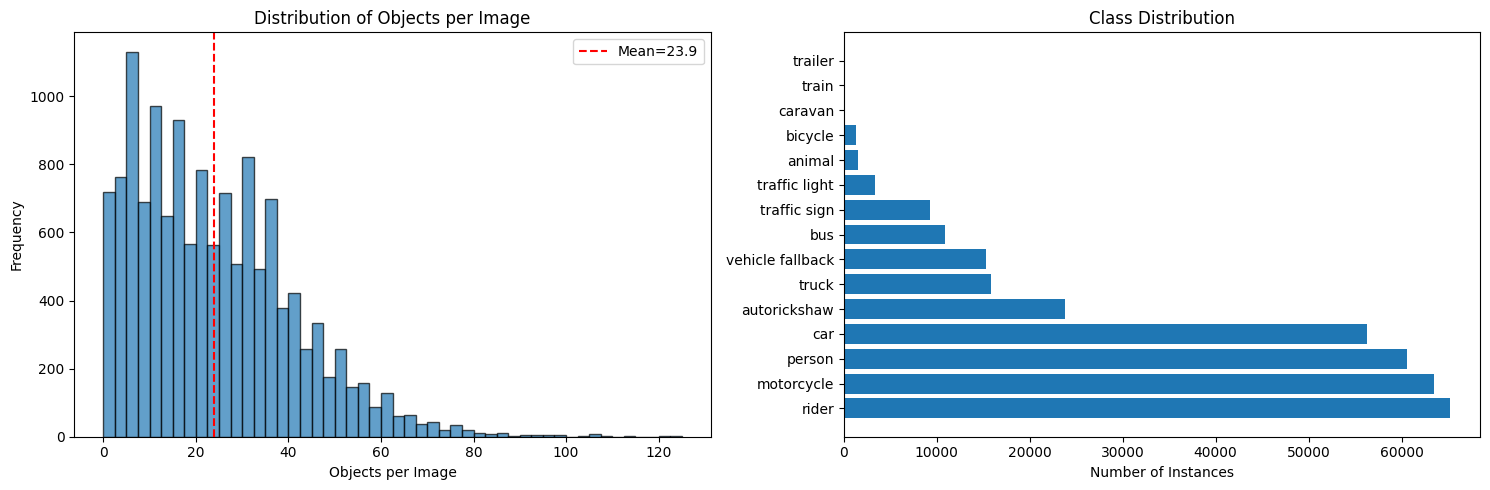

In [ ]:
import os
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# =============================================================================
# DATASET ANALYSIS - Find the Root Cause
# =============================================================================

dataset_path = '/content/road-object-detection-1/data.yaml'

# Load YAML
with open(dataset_path, 'r') as f:
    data = yaml.safe_load(f)

train_labels_path = Path(dataset.location) / 'train' / 'labels' # Fixed: use dataset.location
class_names = data['names']

print("="*60)
print(" DATASET ANALYSIS")
print("="*60)

# Analyze class distribution
class_counts = Counter()
objs_per_image = [] # Renamed for clarity
image_sizes = [] # This variable is not used in the original code, but kept for consistency if it was intended for future use

label_files = list(train_labels_path.glob('*.txt'))
print(f"\n Total label files: {len(label_files)}")

for label_file in label_files:
    with open(label_file, 'r') as f:
        lines = f.readlines()
        objs_per_image.append(len(lines))

        for line in lines:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                class_counts[class_id] += 1

# Print statistics
print(f"\n Objects per image:")
print(f"  - Mean: {np.mean(objs_per_image):.2f}")
print(f"  - Median: {np.median(objs_per_image):.2f}")
print(f"  - Min: {np.min(objs_per_image)}")
print(f"  - Max: {np.max(objs_per_image)}")
print(f"  - Std: {np.std(objs_per_image):.2f}")

# Class distribution
print(f"\n  Class Distribution:")
print(f"{'Class':<20} {'Count':<10} {'Percentage':<10}")
print("-"*40)

total_objects = sum(class_counts.values())
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

for class_id, count in sorted_classes:
    class_name = class_names[class_id] if class_id < len(class_names) else f"Class_{class_id}"
    percentage = (count / total_objects) * 100
    print(f"{class_name:<20} {count:<10} {percentage:>6.2f}%")

# Identify issues
print("\n" + "="*60)
print("  POTENTIAL ISSUES DETECTED:")
print("="*60)

# Check for severe imbalance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count


# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Objects per image histogram
axes[0].hist(objs_per_image, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Objects per Image')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Objects per Image')
axes[0].axvline(np.mean(objs_per_image), color='red', linestyle='--', label=f'Mean={np.mean(objs_per_image):.1f}')
axes[0].legend()

# Plot 2: Class distribution
class_labels = [class_names[i] if i < len(class_names) else f"C{i}" for i, _ in sorted_classes]
class_values = [count for _, count in sorted_classes]
axes[1].barh(class_labels, class_values)
axes[1].set_xlabel('Number of Instances')
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig('/content/dataset_analysis.png', dpi=150, bbox_inches='tight')
print("\n Analysis plot saved to: /content/dataset_analysis.png")

In [ ]:
# =============================================================================
# SOLUTION 1: REMOVE EXTREMELY RARE CLASSES + CLASS WEIGHTS
# =============================================================================
# This will give you the best mAP50 improvement quickly

import os
import yaml
import shutil
from pathlib import Path
import numpy as np

# Classes to REMOVE (too rare to learn - <100 instances)
#CLASSES_TO_REMOVE = [12, 13, 14]  # caravan (48), train (27), trailer (3)

# Also consider removing animal (1509) and bicycle (1265) if still poor
CLASSES_TO_REMOVE = [0,5,9,10,11,12,]  # animal, bicycle, caravan, train, trailer

dataset_path = '/content/road-object-detection-1'
output_path = '/content/road-object-detection-filtered_new'

print(" Creating filtered dataset...")

# Create output directories
for split in ['train', 'valid']:
    os.makedirs(f'{output_path}/{split}/images', exist_ok=True)
    os.makedirs(f'{output_path}/{split}/labels', exist_ok=True)

# Load original yaml
with open(f'{dataset_path}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

original_names = data['names']
print(f"\n Original classes: {len(original_names)}")

# Create new class mapping (remove rare classes)
new_class_mapping = {}
new_names = []
new_idx = 0

for old_idx, name in enumerate(original_names):
    if old_idx not in CLASSES_TO_REMOVE:
        new_class_mapping[old_idx] = new_idx
        new_names.append(name)
        new_idx += 1
    else:
        print(f"    Removing class {old_idx}: {name}")

print(f"\n New classes: {len(new_names)}")
print(f"   {new_names}")

# Process each split
for split in ['train', 'valid']:
    label_dir = Path(f'{dataset_path}/{split}/labels')
    image_dir = Path(f'{dataset_path}/{split}/images')

    out_label_dir = Path(f'{output_path}/{split}/labels')
    out_image_dir = Path(f'{output_path}/{split}/images')

    kept_count = 0
    filtered_count = 0

    for label_file in label_dir.glob('*.txt'):
        # Read and filter labels
        new_lines = []
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])

                    # Skip removed classes
                    if class_id in CLASSES_TO_REMOVE:
                        continue

                    # Remap class ID
                    new_class_id = new_class_mapping[class_id]
                    parts[0] = str(new_class_id)
                    new_lines.append(' '.join(parts) + '\n')

        # Only keep images with at least 1 object
        if new_lines:
            # Save filtered label
            out_label_file = out_label_dir / label_file.name
            with open(out_label_file, 'w') as f:
                f.writelines(new_lines)

            # Copy corresponding image
            image_file = image_dir / label_file.with_suffix('.jpg').name
            if image_file.exists():
                shutil.copy(image_file, out_image_dir / image_file.name)
                kept_count += 1
            else:
                # Try png
                image_file = image_dir / label_file.with_suffix('.png').name
                if image_file.exists():
                    shutil.copy(image_file, out_image_dir / image_file.name)
                    kept_count += 1
        else:
            filtered_count += 1

    print(f"\n{split}:")
    print(f"    Kept: {kept_count} images")
    print(f"    Filtered: {filtered_count} images (no valid objects)")

# Create new data.yaml
new_data = {
    'path': output_path,
    'train': 'train/images',
    'val': 'valid/images',
    'nc': len(new_names),
    'names': new_names
}

with open(f'{output_path}/data.yaml', 'w') as f:
    yaml.dump(new_data, f, sort_keys=False)

print(f"\n Filtered dataset created at: {output_path}")
print(f" New data.yaml saved")

🔧 Creating filtered dataset...

 Original classes: 15
    Removing class 0: animal
    Removing class 5: caravan
    Removing class 9: traffic light
    Removing class 10: traffic sign
    Removing class 11: trailer
    Removing class 12: train

 New classes: 9
   ['autorickshaw', 'bicycle', 'bus', 'car', 'motorcycle', 'person', 'rider', 'truck', 'vehicle fallback']

train:
    Kept: 13588 images
    Filtered: 110 images (no valid objects)

valid:
    Kept: 1286 images
    Filtered: 12 images (no valid objects)

 Filtered dataset created at: /content/road-object-detection-filtered_new
 New data.yaml saved


In [ ]:
# =============================================================================
# SOLUTION 2: COMBINE ALL OBJECT CLASSES INTO ONE (except person)
# =============================================================================

CLASSES_TO_KEEP_PERSON = ['person']

dataset_path = '/content/road-object-detection-filtered_new'  # your filtered dataset
output_path = '/content/road-object-detection-binary'

print(" Creating binary dataset...")

# Create output directories
for split in ['train', 'valid']:
    os.makedirs(f'{output_path}/{split}/images', exist_ok=True)
    os.makedirs(f'{output_path}/{split}/labels', exist_ok=True)

# Load original yaml
with open(f'{dataset_path}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

original_names = data['names']
print(f"\n Original classes: {len(original_names)} -> {original_names}")

# Create new mapping: person -> 0, all else -> 1
new_class_mapping = {}
new_names = ['person', 'vehicle']

for idx, name in enumerate(original_names):
    if name == 'person':
        new_class_mapping[idx] = 0
    else:
        new_class_mapping[idx] = 1

# Process each split
for split in ['train', 'valid']:
    label_dir = Path(f'{dataset_path}/{split}/labels')
    image_dir = Path(f'{dataset_path}/{split}/images')

    out_label_dir = Path(f'{output_path}/{split}/labels')
    out_image_dir = Path(f'{output_path}/{split}/images')

    kept_count = 0
    filtered_count = 0

    for label_file in label_dir.glob('*.txt'):
        new_lines = []
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    new_class_id = new_class_mapping[class_id]
                    parts[0] = str(new_class_id)
                    new_lines.append(' '.join(parts) + '\n')

        # Keep images with at least 1 object
        if new_lines:
            out_label_file = out_label_dir / label_file.name
            with open(out_label_file, 'w') as f:
                f.writelines(new_lines)

            # Copy corresponding image
            image_file = image_dir / label_file.with_suffix('.jpg').name
            if image_file.exists():
                shutil.copy(image_file, out_image_dir / image_file.name)
                kept_count += 1
            else:
                # Try png
                image_file = image_dir / label_file.with_suffix('.png').name
                if image_file.exists():
                    shutil.copy(image_file, out_image_dir / image_file.name)
                    kept_count += 1
        else:
            filtered_count += 1

    print(f"\n{split}:")
    print(f"    Kept: {kept_count} images")
    print(f"   Filtered: {filtered_count} images (no valid objects)")

# Create new data.yaml
new_data = {
    'path': output_path,
    'train': 'train/images',
    'val': 'valid/images',
    'nc': len(new_names),
    'names': new_names
}

with open(f'{output_path}/data.yaml', 'w') as f:
    yaml.dump(new_data, f, sort_keys=False)

print(f"\n Binary dataset created at: {output_path}")
print(f"New data.yaml saved with classes: {new_names}")


 Creating binary dataset...

 Original classes: 9 -> ['autorickshaw', 'bicycle', 'bus', 'car', 'motorcycle', 'person', 'rider', 'truck', 'vehicle fallback']

train:
    Kept: 13588 images
   Filtered: 0 images (no valid objects)

valid:
    Kept: 1286 images
   Filtered: 0 images (no valid objects)

 Binary dataset created at: /content/road-object-detection-binary
New data.yaml saved with classes: ['person', 'vehicle']


In [ ]:
# =============================================================================
# TRAIN WITH FILTERED DATASET + CLASS WEIGHTS
# =============================================================================
from ultralytics import YOLO

print("\n Starting training with filtered dataset...")

model = YOLO('/content/drive/MyDrive/YOLOv8_RoadDetection/road_detection_filtered_binary/weights/last.pt')  # Use medium model for better accuracy

# Note: YOLOv8 doesn't directly support class weights in train()
# but the balanced dataset will help significantly
results = model.train(
    # Dataset Configuration
    data='/content/road-object-detection-binary/data.yaml', # FIX: Changed to point to the data.yaml file
    # Training Parameters
    epochs=100,                    # Number of training epochs
    imgsz=640,                     # Image size (640x640)
    batch=16,                      # Batch size (adjust based on GPU memory)

    # Learning Rate & Optimization
    lr0=0.02,                      # Initial learning rate
    lrf=0.1,                      # Final learning rate (lr0 * lrf)
    momentum=0.937,                # SGD momentum
    weight_decay=0.0005,           # Optimizer weight decay
    warmup_epochs=3.0,             # Warmup epochs
    warmup_momentum=0.8,           # Warmup initial momentum
    warmup_bias_lr=0.1,            # Warmup initial bias lr

    # Data Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.0,
    # Removed duplicate 'erasing=0.0'

    # Model Configuration
    patience=50,                   # Early stopping patience (epochs)
    save=True,                     # Save checkpoints
    save_period=1,                # Save checkpoint every x epochs
    cache=True,                    # Cache images for faster training
    device=0,                      # GPU device (0 or cpu)
    workers=8,                     # Number of worker threads
    project='/content/drive/MyDrive/YOLOv8_RoadDetection',              # Project name
    name='road_detection_filtered_binary',     # Experiment name
    exist_ok=True,                 # Overwrite existing project
    pretrained=True,               # Use pretrained weights
    optimizer='auto',              # Optimizer (auto, SGD, Adam, AdamW)
    verbose=True,                  # Verbose output
    seed=0,                        # Random seed for reproducibility
    deterministic=False,            # Deterministic mode
    single_cls=False,              # Train as single-class dataset
    cos_lr=False,                  # Cosine LR scheduler
    close_mosaic=10,               # Disable mosaic for final epochs
    resume=True,                  # Set to False to start new training
    amp=True,                      # Automatic Mixed Precision training
    fraction=1.0,                  # Dataset fraction to train on
    profile=False,                 # Profile ONNX and TensorRT speeds
    freeze=None,                   # Freeze layers (list or int)

    # Validation
    val=True,                      # Validate during training
    plots=True,                    # Save training plots

    # Advanced Augmentation
    erasing=0.4,                   # Random erasing probability
    crop_fraction=1.0              # Image crop fraction
)

print("\n Training completed!")


 Starting training with filtered dataset...
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road-object-detection-binary/data.yaml, degrees=0.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.02, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/YOLOv8_RoadDetection/road_detection_filtere

In [ ]:
# =============================================================================
# 6. SAVE BEST AND LAST MODELS TO GOOGLE DRIVE
# =============================================================================
print("\n Saving models to Google Drive...")

# Get the run directory
run_dir = Path(save_dir) / 'road_detection_filtered_two'

# Copy best and last weights to a specific location
import shutil

best_model_src = run_dir / 'weights' / 'best.pt'
last_model_src = run_dir / 'weights' / 'last.pt'

best_model_dst = Path(save_dir) / 'best_model.pt'
last_model_dst = Path(save_dir) / 'last_model.pt'

if best_model_src.exists():
    shutil.copy(best_model_src, best_model_dst)
    print(f" Best model saved to: {best_model_dst}")

if last_model_src.exists():
    shutil.copy(last_model_src, last_model_dst)
    print(f" Last model saved to: {last_model_dst}")


 Saving models to Google Drive...
 Best model saved to: /content/drive/MyDrive/YOLOv8_RoadDetection/best_model.pt
 Last model saved to: /content/drive/MyDrive/YOLOv8_RoadDetection/last_model.pt


In [ ]:
# =============================================================================
# 7. EVALUATE MODEL
# =============================================================================
print("\n Evaluating model on validation set...")
metrics = model.val()

print("\n" + "="*60)
print(" TRAINING COMPLETED!")
print("="*60)
print(f"\n Results:")
print(f"   - mAP50: {metrics.box.map50:.4f}")
print(f"   - mAP50-95: {metrics.box.map:.4f}")
print(f"   - Precision: {metrics.box.mp:.4f}")
print(f"   - Recall: {metrics.box.mr:.4f}")
print(f"\n Models saved to: {save_dir}")
print(f"   - Best: {best_model_dst}")
print(f"   - Last: {last_model_dst}")


 Evaluating model on validation set...
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 202.8±398.2 MB/s, size: 56.4 KB)
val: Scanning /content/road-object-detection-binary/valid/labels.cache... 1286 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1286/1286 1.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 81/81 4.3it/s 18.9s
                   all       1286      29802      0.714      0.456      0.518      0.303
                person        899       5355      0.671      0.352      0.409      0.213
               vehicle       1274      24447      0.756      0.561      0.628      0.392
Speed: 1.6ms preprocess, 4.0ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val

🎉 TRAINING COMPLETED!

 Results:
   - m